1. Train a deep MLP on the MNIST dataset, you can load it using keras.datasets.mnist.load_data(). 
- See if you can get over 98% precision. Try searching for the optimal learning rate (i.e., by growing the learning rate exponentially, plotting the error, and finding the point where the error shoots up), and plot learning curves using TensorBoard.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

Load and normalize image data 

In [6]:
GrayScale = 255

x_train = x_train.astype('float32') / GrayScale
x_test = x_test.astype('float32') / GrayScale

x_train = np.expand_dims(x_train, axis=-1)  # Shape becomes (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)    # Shape becomes (10000, 28, 28, 1)
print(f"feature matrix x_train {x_train.shape}")
print(f"target matrix y:train {y_train.shape}")
print(f"feature matrix x_test {y_test.shape}")
print(f"target matrix y_test {y_test.shape}")

feature matrix x_train (60000, 28, 28, 1)
target matrix y:train (60000,)
feature matrix x_test (10000,)
target matrix y_test (10000,)


Some visualization

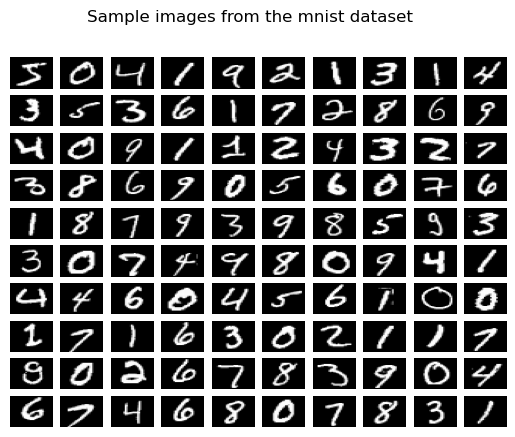

In [7]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto', cmap='gray')
        ax[i][j].axis('off')
        k += 1
fig.suptitle("Sample images from the mnist dataset")
plt.show()

Building the Neural network


In [ ]:
model = Sequential(
    [
        Flatten(input_shape=(28, 28)),
        Dense(512, activation='relu'),
        Dropout(.3),
        Dense(256, activation='relu'),
        Dropout(.3),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax'),
    ]
)

/home/Nilse/.conda/envs/tf2/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-02-12 16:20:40.797525: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
from tensorflow.keras.metrics import Precision
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),

              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Eraly stop


In [10]:
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# remove some channels
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
datagen = ImageDataGenerator(
    rotation_range=10,       # Randomly rotate images by up to 10 degrees
    width_shift_range=0.1,   # Randomly shift images horizontally by 10% of the width
    height_shift_range=0.1,  # Randomly shift images vertically by 10% of the height
    zoom_range=0.1,          # Randomly zoom images by up to 10%
    shear_range=0.1,         # Shear transformations
    horizontal_flip=False,   # Set to True if horizontal flipping is relevant
    fill_mode='nearest'      # Fill in missing pixels after transformations
)

In [12]:

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Verify the shapes
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [13]:
datagen.fit(x_train)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(datagen.flow(x_train, y_train, batch_size=32),
          epochs=100,
          validation_data=(x_test, y_test),
          callbacks=[early_stop])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8356 - loss: 0.5130 - val_accuracy: 0.9604 - val_loss: 0.1236
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9171 - loss: 0.2722 - val_accuracy: 0.9705 - val_loss: 0.0956
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9276 - loss: 0.2349 - val_accuracy: 0.9674 - val_loss: 0.1009
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9368 - loss: 0.2111 - val_accuracy: 0.9749 - val_loss: 0.0769
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9410 - loss: 0.1941 - val_accuracy: 0.9773 - val_loss: 0.0717
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9441 - loss: 0.1830 - val_accuracy: 0.9783 - val_loss: 0.0695
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9476 - loss: 0.1735 - val_accuracy: 0.9775 - val_loss: 0.0685
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9494 - loss: 0

In [15]:
from sklearn.metrics import precision_score

In [16]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.054807908833026886, 0.9819999933242798]


In [17]:
mod = model.fit(x_train, y_train, epochs=10,
                batch_size=2000,
                validation_split=0.2)

print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9730 - loss: 0.0895 - val_accuracy: 0.9861 - val_loss: 0.0496
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9756 - loss: 0.0788 - val_accuracy: 0.9868 - val_loss: 0.0445
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9787 - loss: 0.0713 - val_accuracy: 0.9874 - val_loss: 0.0430
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9786 - loss: 0.0704 - val_accuracy: 0.9877 - val_loss: 0.0417
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9800 - loss: 0.0673 - val_accuracy: 0.9879 - val_loss: 0.0405
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9804 - loss: 0.0639 - val_accuracy: 0.9880 - val_loss: 0.0395
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9805 - loss: 0.0622 - val_accuracy: 0.9887 - val_loss: 0.0389
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9815 - loss: 0.0593 - val_accuracy: 0.9889 - v

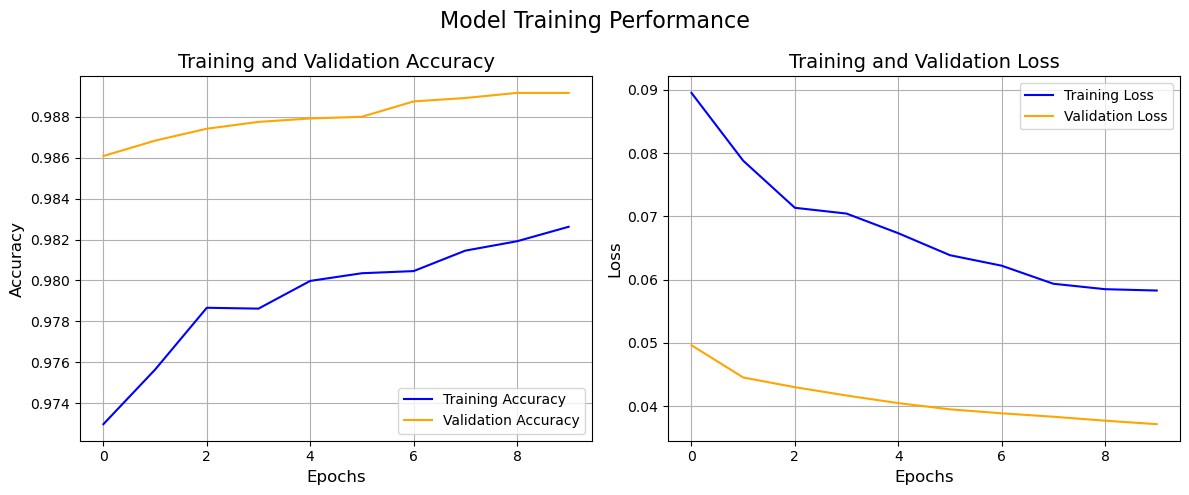

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import precision_score

# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate precision
precision = precision_score(y_test, y_pred_classes, average='weighted')
print(f'Precision: {precision:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
Precision: 0.9888
